# Library

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import os

from scipy.stats import pearsonr
from google.colab import drive
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Data

In [16]:
drive.mount('/content/gdrive')
data = pd.read_csv('/content/gdrive/My Drive/JST/datakemiskinan.csv')

print("Data awal:")
print(data.head())

# Ubah nilai kolom menjadi numerik
numeric_cols = ['Pen_Miskin', 'Pengangguran', 'Laju_Pertumbuhan_PDRB', 'IPM']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(data[numeric_cols].describe())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Data awal:
    Tahun Kabupaten  Pen_Miskin Pengangguran  Laju_Pertumbuhan_PDRB    IPM
0  2017.0     Kobar     13270.0         3213                   3.68  72.11
1  2018.0     Kobar     12900.0         4646                   3.42  72.46
2  2019.0     Kobar     12760.0         4318                   6.67  72.85
3  2020.0     Kobar     11460.0         8136                  12.75  73.95
4  2021.0     Kobar     12290.0         7850                   4.36  74.15

Statistik Deskriptif:
         Pen_Miskin  Pengangguran  Laju_Pertumbuhan_PDRB         IPM
count    126.000000    126.000000             126.000000  126.000000
mean   10034.841270   4162.277778               3.223333   72.164286
std     6540.276659   3003.627949               4.156223    3.411881
min     1960.000000    569.000000             -17.200000   66.140000
25%     6177.500000   1770.250000       

# Cek Missing Value

In [17]:
kolom = ['Pen_Miskin', 'Pengangguran', 'Laju_Pertumbuhan_PDRB', 'IPM']

print("\nCek Missing Value:")
print(data[kolom].isnull().sum())

# Tangani missing value (hapus baris yang mengandung NaN pada kolom tersebut)
data = data.dropna(subset=kolom)

print("\nData setelah hapus missing value:")
print(data[kolom].isnull().sum())


Cek Missing Value:
Pen_Miskin               2
Pengangguran             2
Laju_Pertumbuhan_PDRB    2
IPM                      2
dtype: int64

Data setelah hapus missing value:
Pen_Miskin               0
Pengangguran             0
Laju_Pertumbuhan_PDRB    0
IPM                      0
dtype: int64


# Cek Outlier

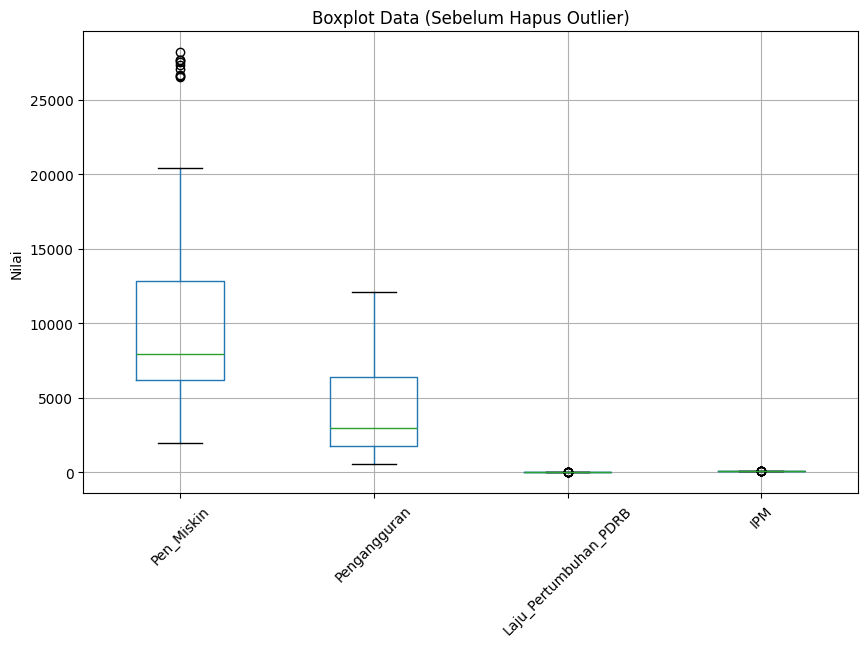


Jumlah outlier tiap variabel:
Pen_Miskin                9
Pengangguran              0
Laju_Pertumbuhan_PDRB    10
IPM                       9
dtype: int64


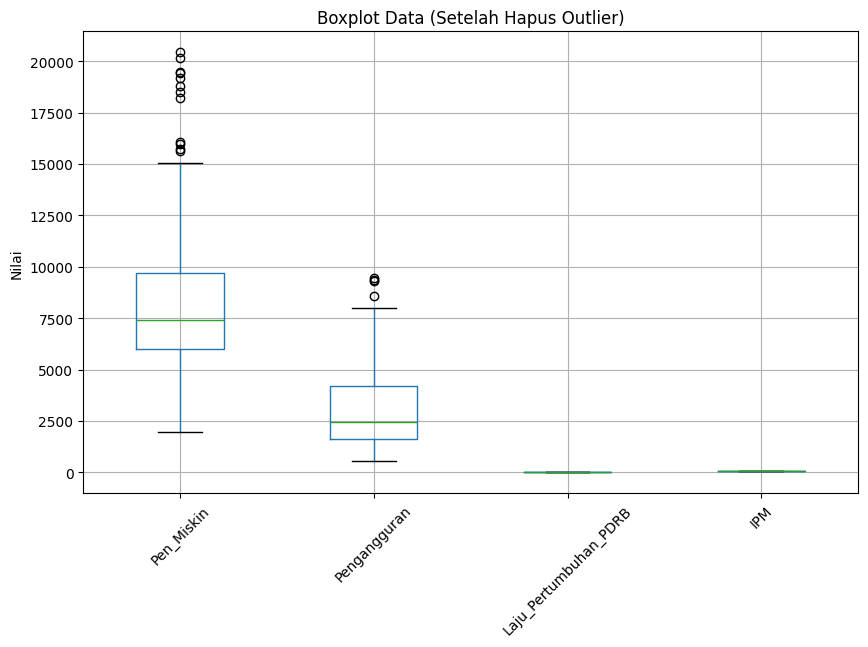


Jumlah outlier tiap variabel (SETELAH dibersihkan):
Pen_Miskin               12
Pengangguran              4
Laju_Pertumbuhan_PDRB     0
IPM                       0
dtype: int64


In [18]:
Q1 = data[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']].quantile(0.25)
Q3 = data[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']].quantile(0.75)
IQR = Q3 - Q1

outlier = ((data[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']] < (Q1 - 1.5 * IQR)) |
           (data[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']] > (Q3 + 1.5 * IQR)))

plt.figure(figsize=(10,6))
data[kolom].boxplot()
plt.title("Boxplot Data (Sebelum Hapus Outlier)")
plt.ylabel("Nilai")
plt.xticks(rotation=45)
plt.show()

print("\nJumlah outlier tiap variabel:")
print(outlier.sum())

# Hapus data yang mengandung outlier
data_clean = data[~outlier.any(axis=1)]

plt.figure(figsize=(10,6))
data_clean[kolom].boxplot()
plt.title("Boxplot Data (Setelah Hapus Outlier)")
plt.ylabel("Nilai")
plt.xticks(rotation=45)
plt.show()

Q1_clean = data_clean[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']].quantile(0.25)
Q3_clean = data_clean[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']].quantile(0.75)
IQR_clean = Q3_clean - Q1_clean

outlier_clean = ((data_clean[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']] < (Q1_clean - 1.5 * IQR_clean)) |
                 (data_clean[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']] > (Q3_clean + 1.5 * IQR_clean)))

print("\nJumlah outlier tiap variabel (SETELAH dibersihkan):")
print(outlier_clean.sum())

# Korelasi Pearson


Korelasi Pearson


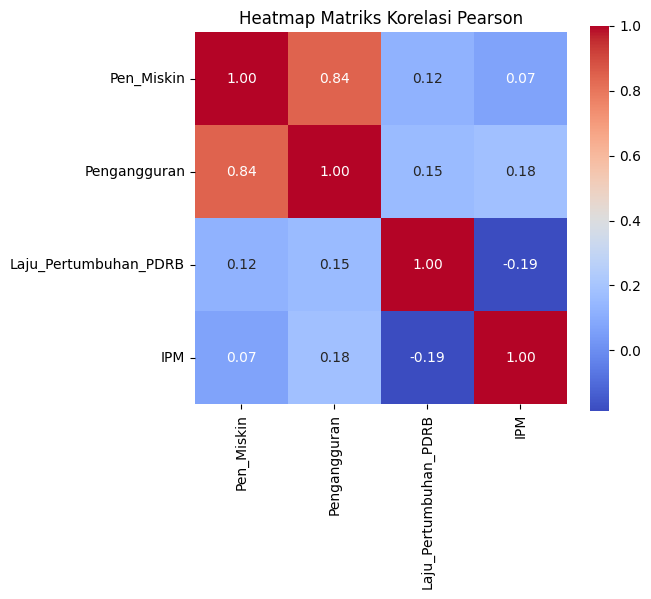


Korelasi dengan Pen_Miskin:
Pengangguran: r = 0.845, p-value = 0.0000
Interpretasi: Hubungan positif dengan kekuatan kuat.
Laju_Pertumbuhan_PDRB: r = 0.122, p-value = 0.2251
Interpretasi: Hubungan positif dengan kekuatan lemah.
IPM: r = 0.069, p-value = 0.4952
Interpretasi: Hubungan positif dengan kekuatan lemah.


In [19]:
print("\nKorelasi Pearson")
corr_matrix = data_clean[['Pen_Miskin','Pengangguran','Laju_Pertumbuhan_PDRB','IPM']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap Matriks Korelasi Pearson")
plt.show()

print("\nKorelasi dengan Pen_Miskin:")
for var in ['Pengangguran','Laju_Pertumbuhan_PDRB','IPM']:
    r, p = pearsonr(data_clean['Pen_Miskin'], data_clean[var])
    arah = "positif" if r > 0 else "negatif"
    kekuatan = "lemah" if abs(r) < 0.3 else "sedang" if abs(r) < 0.6 else "kuat"
    print(f"{var}: r = {r:.3f}, p-value = {p:.4f}")
    print(f"Interpretasi: Hubungan {arah} dengan kekuatan {kekuatan}.")

# Definisikan Variabel

In [20]:
Y = data_clean['Pen_Miskin']
X = data_clean[['Pengangguran','Laju_Pertumbuhan_PDRB','IPM']]
X = sm.add_constant(X)

# Model Regresi Linear

In [21]:
model = sm.OLS(Y, X).fit()
print("\nHasil Regresi:")
print(model.summary())

# Menampilkan Model
b0 = model.params['const']
b1 = model.params['Pengangguran']
b2 = model.params['Laju_Pertumbuhan_PDRB']
b3 = model.params['IPM']

print("\nPersamaan Model Regresi")
print(f"Y = {b0:.3f} + ({b1:.3f})*X1 + ({b2:.3f})*X2 + ({b3:.3f})*X3")

r2 = model.rsquared
adj_r2 = model.rsquared_adj

print(f"\nR-square = {r2:.3f}")
print(f"Adjusted R-square = {adj_r2:.3f}")

print("\nInterpretasi R-square:")
print(f"Nilai R-square sebesar {r2:.3f} menunjukkan bahwa "
      f"{r2*100:.2f}% variasi jumlah penduduk miskin "
      f"dapat dijelaskan oleh variabel Pengangguran, "
      f"Laju Pertumbuhan PDRB, dan IPM secara bersama-sama, "
      f"sedangkan sisanya sebesar {(1-r2)*100:.2f}% dijelaskan oleh "
      f"faktor lain di luar model.")


Hasil Regresi:
                            OLS Regression Results                            
Dep. Variable:             Pen_Miskin   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     82.63
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           1.69e-26
Time:                        01:40:43   Log-Likelihood:                -924.16
No. Observations:                 100   AIC:                             1856.
Df Residuals:                      96   BIC:                             1867.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const         

# Uji Asumsi Klasik

In [22]:
residual = model.resid

# Normalitas
stat, p = shapiro(residual)
print("\nUji Normalitas (Shapiro-Wilk):")
print("Statistik =", stat, "p-value =", p)
if p > 0.05:
    print(f"Karena nilai p-value {p} > 0.05, maka residual berdistribusi normal (asumsi normalitas terpenuhi).")
else:
    print(f"Karena nilai p-value {p} < 0.05, maka residual tidak berdistribusi normal (asumsi normalitas tidak terpenuhi).")

# Multikolinearitas (VIF)
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nUji Multikolinearitas (VIF):")
print(vif_data)
if (vif_data["VIF"] < 10).all():
    print("Interpretasi: Tidak terdapat multikolinearitas antar variabel bebas.")
else:
    print("Interpretasi: Terdapat multikolinearitas pada beberapa variabel bebas.")

# Heteroskedastisitas
bp_test = het_breuschpagan(residual, X)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_result = dict(zip(labels, bp_test))

print("\nUji Heteroskedastisitas (Breusch-Pagan):")
print(bp_result)

if bp_result['LM-Test p-value'] > 0.05:
    print("Interpretasi: Tidak terjadi heteroskedastisitas (model bersifat homoskedastis).")
else:
    print("Interpretasi: Terjadi heteroskedastisitas (asumsi homoskedastisitas tidak terpenuhi).")

# Autokorelasi
dw = durbin_watson(residual)
print("\nUji Autokorelasi (Durbin-Watson):")
print("Nilai DW =", dw)
if 1.5 < dw < 2.5:
    print("Interpretasi: Tidak terdapat autokorelasi pada residual.")
elif dw <= 1.5:
    print("Interpretasi: Terdapat autokorelasi positif.")
else:
    print("Interpretasi: Terdapat autokorelasi negatif.")


Uji Normalitas (Shapiro-Wilk):
Statistik = 0.9710307607650142 p-value = 0.026523394995064672
Karena nilai p-value 0.026523394995064672 < 0.05, maka residual tidak berdistribusi normal (asumsi normalitas tidak terpenuhi).

Uji Multikolinearitas (VIF):
                Variabel         VIF
0                  const  978.852655
1           Pengangguran    1.071525
2  Laju_Pertumbuhan_PDRB    1.075148
3                    IPM    1.083814
Interpretasi: Terdapat multikolinearitas pada beberapa variabel bebas.

Uji Heteroskedastisitas (Breusch-Pagan):
{'LM Statistic': np.float64(9.164020285722764), 'LM-Test p-value': np.float64(0.027187792947106257), 'F-Statistic': np.float64(3.2283314394311176), 'F-Test p-value': np.float64(0.02585560690921077)}
Interpretasi: Terjadi heteroskedastisitas (asumsi homoskedastisitas tidak terpenuhi).

Uji Autokorelasi (Durbin-Watson):
Nilai DW = 0.47718177778338994
Interpretasi: Terdapat autokorelasi positif.


# Prediksi

In [23]:
data_clean['prediksi_kemiskinan'] = model.predict(X)

/tmp/ipykernel_7771/4251703308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['prediksi_kemiskinan'] = model.predict(X)


# Evaluasi Model

In [24]:
rmse = np.sqrt(mean_squared_error(Y, data_clean['prediksi_kemiskinan']))
mae = mean_absolute_error(Y, data_clean['prediksi_kemiskinan'])
mape = np.mean(np.abs((Y - data_clean['prediksi_kemiskinan']) / Y)) * 100

print("\nEvaluasi Model:")
print("RMSE =", rmse)
print("MAE  =", mae)
print("MAPE =", mape, "%")

print("\nInterpretasi Evaluasi Model:")
print(f"RMSE sebesar {rmse:.3f} menunjukkan rata-rata besar kesalahan prediksi dalam satuan yang sama dengan variabel kemiskinan.")
print(f"MAE sebesar {mae:.3f} menunjukkan rata-rata kesalahan absolut antara nilai aktual dan nilai prediksi.")
if mape < 10:
    print(f"MAPE sebesar {mape:.2f}% menunjukkan model memiliki akurasi sangat baik.")
elif mape < 20:
    print(f"MAPE sebesar {mape:.2f}% menunjukkan model memiliki akurasi baik.")
elif mape < 50:
    print(f"MAPE sebesar {mape:.2f}% menunjukkan model memiliki akurasi cukup.")
else:
    print(f"MAPE sebesar {mape:.2f}% menunjukkan model memiliki akurasi rendah.")


Evaluasi Model:
RMSE = 2496.475559608802
MAE  = 2014.0182274086972
MAPE = 35.767245292408134 %

Interpretasi Evaluasi Model:
RMSE sebesar 2496.476 menunjukkan rata-rata besar kesalahan prediksi dalam satuan yang sama dengan variabel kemiskinan.
MAE sebesar 2014.018 menunjukkan rata-rata kesalahan absolut antara nilai aktual dan nilai prediksi.
MAPE sebesar 35.77% menunjukkan model memiliki akurasi cukup.


# Hasil Prediksi

In [28]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

hasil = data_clean[['Kabupaten','Tahun','Pen_Miskin','prediksi_kemiskinan']]
print("\nTabel Hasil Prediksi:")
print(hasil)


Tabel Hasil Prediksi:
       Kabupaten   Tahun  Pen_Miskin  prediksi_kemiskinan
0          Kobar  2017.0     13270.0          8364.044717
1          Kobar  2018.0     12900.0         11093.714951
2          Kobar  2019.0     12760.0         10145.220968
4          Kobar  2021.0     12290.0         16923.497137
5          Kobar  2022.0     12440.0         16243.018560
6          Kobar  2023.0     13440.0         13642.937599
7          Kobar  2024.0     13430.0         14133.807274
8          Kobar  2025.0     14180.0         14058.738850
18        Kapuas  2017.0     18800.0         20686.611027
19        Kapuas  2018.0     18520.0         16667.886798
20        Kapuas  2019.0     18230.0         20455.356798
22        Kapuas  2021.0     19450.0         20632.119032
23        Kapuas  2022.0     20180.0         16029.062802
24        Kapuas  2023.0     19180.0         17494.995751
25        Kapuas  2024.0     19470.0         18568.777715
26        Kapuas  2025.0     20430.0         1736

# Plot Grafik

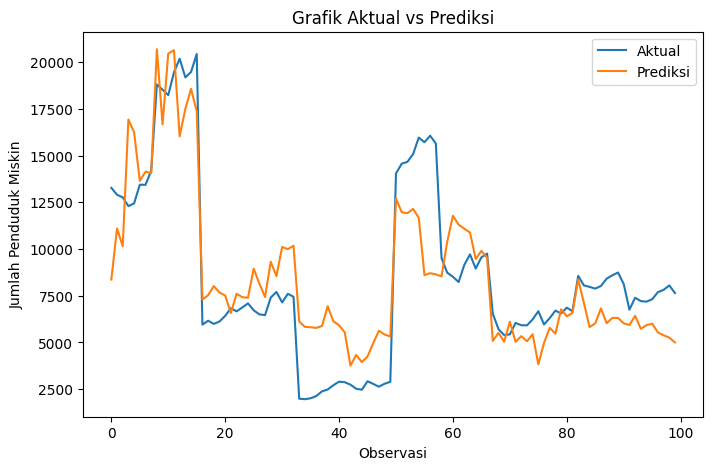

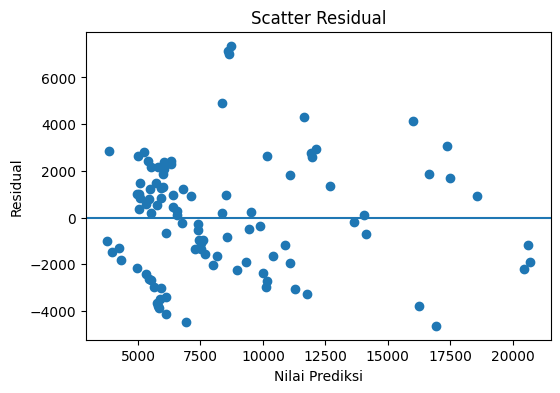

In [26]:
# Plot Grafik Aktual vs Prediksi
plt.figure(figsize=(8,5))
plt.plot(Y.values, label='Aktual')
plt.plot(data_clean['prediksi_kemiskinan'].values, label='Prediksi')
plt.xlabel('Observasi')
plt.ylabel('Jumlah Penduduk Miskin')
plt.title('Grafik Aktual vs Prediksi')
plt.legend()
plt.show()

# Plot Grafik residual
plt.figure(figsize=(6,4))
plt.scatter(data_clean['prediksi_kemiskinan'], residual)
plt.axhline(0)
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Scatter Residual')
plt.show()